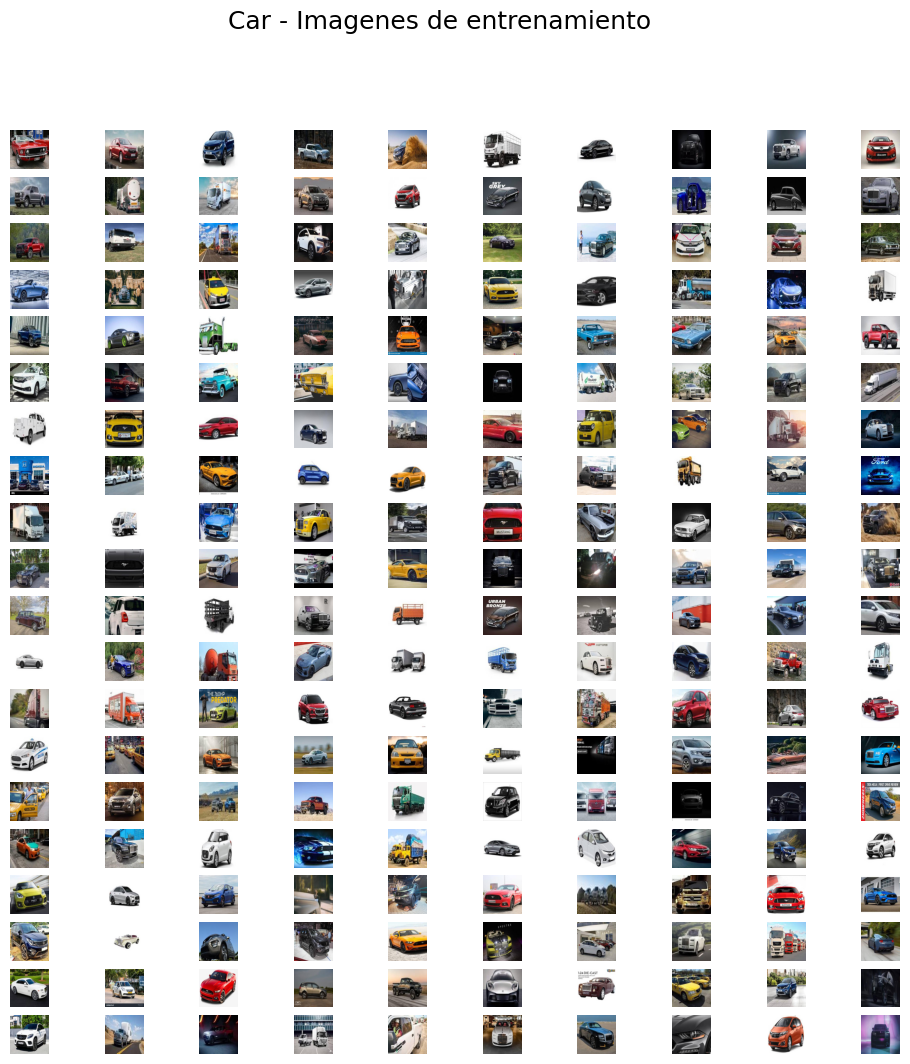

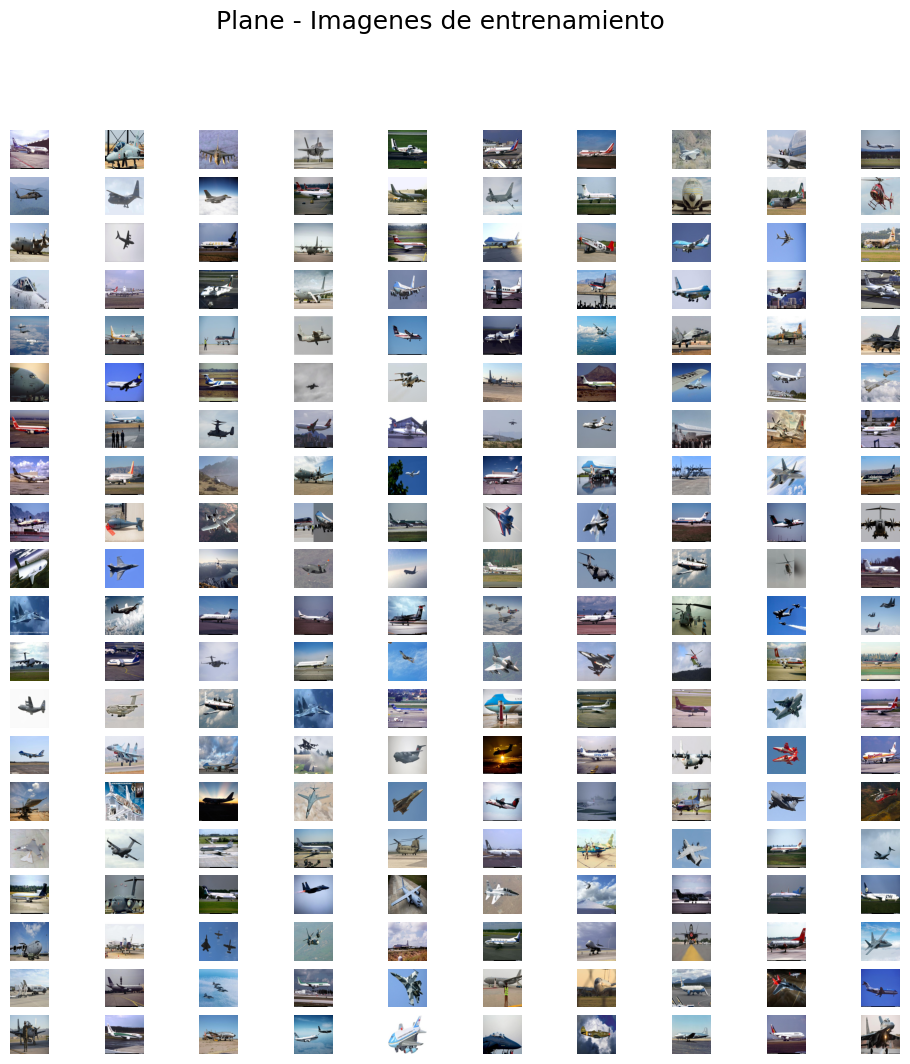

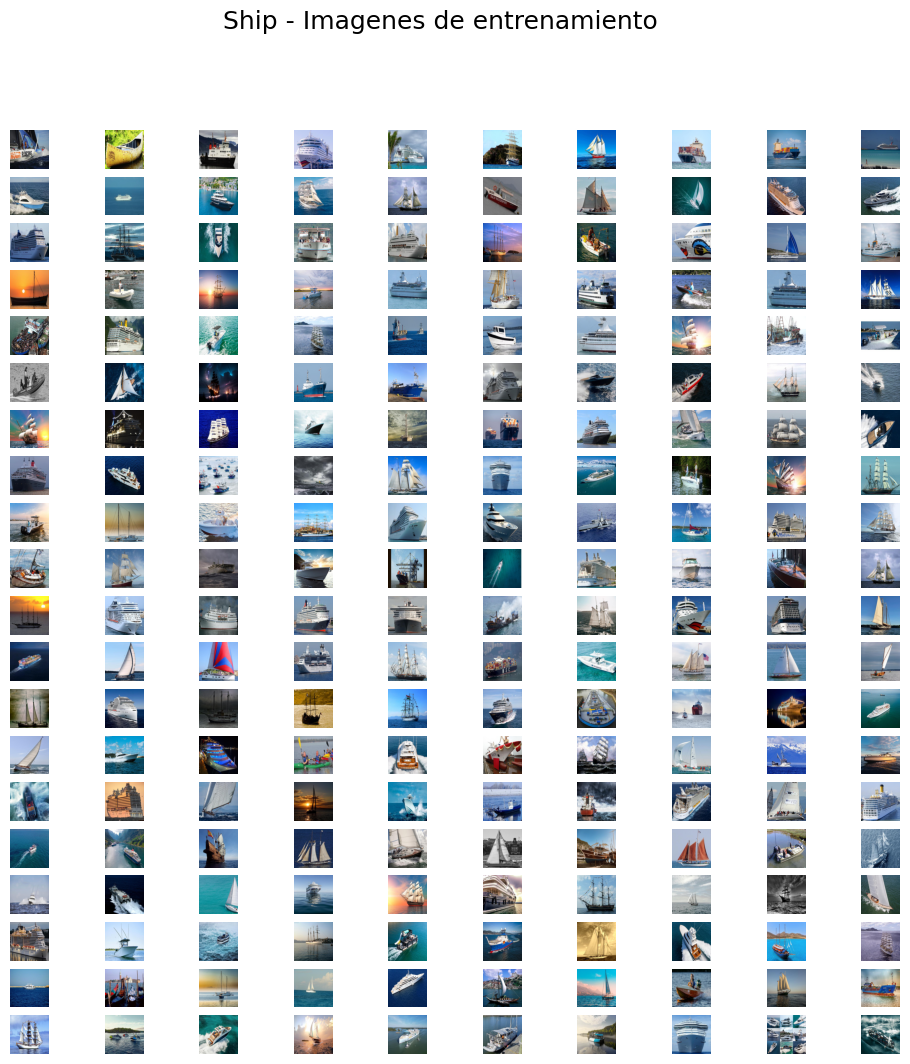

Cargando entrenamiento...

Centroides normalizados
Cars: [-0.18369895 -0.1625759  -0.24390018 -0.20374093 -0.31496174 -0.09224145
 -0.16179335 -0.03412794  0.1987921  -0.27070128]
Planes: [ 0.26530726  0.19261197  0.19566943  0.09128273  0.06394165 -0.12730531
 -0.03258034 -0.0328102  -0.13395054  0.20355225]
Ships: [-0.08160831 -0.03003607  0.04823074  0.11245821  0.25102009  0.21954675
  0.1943737   0.06693814 -0.06484156  0.06714903]

Cargando datos de prueba...

MATRIZ CONFUSION
        Cars  Planes  Ships
Cars     329      55    116
Planes    33     361    106
Ships     42      70    388

MATRIZ CONFUSION (%)
        Cars  Planes  Ships
Cars    65.8    11.0   23.2
Planes   6.6    72.2   21.2
Ships    8.4    14.0   77.6

ACCURACY DEL CLASIFICADOR
Clasificaciones correctas: 1078
Total de muestras: 1500
Accuracy: 71.87 %

Clasificacion de imagen
Categoria predicha: Planes


In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from skimage.feature import hog, local_binary_pattern

# =====================================================
# VISUALIZAR IMAGENES DE ENTRENAMIENTO
# =====================================================

def visualizar_categoria(carpeta, prefijo):

    carpeta = Path("dataset") / carpeta

    plt.figure(figsize=(12,12))
    plt.suptitle(prefijo + " - Imagenes de entrenamiento", fontsize=18)

    for i in range(1,201):

        ruta = carpeta / f"{prefijo} ({i}).jpg"

        img = cv2.imread(str(ruta))

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(20,10,i)   # 200 imagenes

        plt.imshow(img)

        plt.axis("off")

    plt.show()


# =====================================================
# MOSTRAR CADA CATEGORIA
# =====================================================

visualizar_categoria("cars","Car")

visualizar_categoria("planes","Plane")

visualizar_categoria("ships","Ship")
# =====================================================
# CONFIGURACION
# =====================================================

TRAIN_IMAGES = 200
TEST_IMAGES = 500

PATH_CARS = "dataset/cars"
PATH_PLANES = "dataset/planes"
PATH_SHIPS = "dataset/ships"


# =====================================================
# DESCRIPTORES
# =====================================================

def descriptor_hog(gray):

    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        feature_vector=True
    )


def descriptor_lbp(gray):

    lbp = local_binary_pattern(gray,16,2,method='uniform')

    bins = int(lbp.max()+1)

    hist,_ = np.histogram(
        lbp.ravel(),
        bins=bins,
        range=(0,bins),
        density=True
    )

    return hist


def descriptor_color(img):

    hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])

    hist = cv2.normalize(hist,hist).flatten()

    return hist


def descriptor_imagen(img):

    img = cv2.resize(img,(128,128))

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    hog_f = descriptor_hog(gray)
    lbp_f = descriptor_lbp(gray)
    color_f = descriptor_color(img)

    return np.concatenate([hog_f,lbp_f,color_f])


# =====================================================
# KERNEL RBF
# =====================================================

def kernel_rbf(x,c):

    gamma = 0.002

    return np.exp(-gamma*np.linalg.norm(x-c)**2)


# =====================================================
# CLASIFICADOR
# =====================================================

def clasificar(x,centroids):

    scores = []

    for c in centroids:

        score = kernel_rbf(x,c)

        scores.append(score)

    return np.argmax(scores)


# =====================================================
# CARGAR DATASET
# =====================================================

def cargar_categoria(path,cantidad,inicio):

    archivos = sorted(os.listdir(path))[inicio:inicio+cantidad]

    data = []

    for f in archivos:

        img = cv2.imread(os.path.join(path,f))

        if img is not None:

            desc = descriptor_imagen(img)

            data.append(desc)

    return np.array(data)


# =====================================================
# CARGAR DATABASE
# =====================================================

print("Cargando entrenamiento...")

cars_train = cargar_categoria(PATH_CARS,TRAIN_IMAGES,0)
planes_train = cargar_categoria(PATH_PLANES,TRAIN_IMAGES,0)
ships_train = cargar_categoria(PATH_SHIPS,TRAIN_IMAGES,0)

X_train = np.vstack((cars_train,planes_train,ships_train))

y_train = np.array(
    [0]*TRAIN_IMAGES +
    [1]*TRAIN_IMAGES +
    [2]*TRAIN_IMAGES
)


# =====================================================
# NORMALIZACION
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)


# =====================================================
# CENTROIDES NORMALIZADOS
# =====================================================

centroids = np.vstack([
np.mean(X_train[y_train==0],axis=0),
np.mean(X_train[y_train==1],axis=0),
np.mean(X_train[y_train==2],axis=0)
])

print("\nCentroides normalizados")

print("Cars:",centroids[0][:10])
print("Planes:",centroids[1][:10])
print("Ships:",centroids[2][:10])


# =====================================================
# CARGAR TEST
# =====================================================

print("\nCargando datos de prueba...")

cars_test = cargar_categoria(PATH_CARS,TEST_IMAGES,TRAIN_IMAGES)
planes_test = cargar_categoria(PATH_PLANES,TEST_IMAGES,TRAIN_IMAGES)
ships_test = cargar_categoria(PATH_SHIPS,TEST_IMAGES,TRAIN_IMAGES)

X_test = np.vstack((cars_test,planes_test,ships_test))

X_test = scaler.transform(X_test)

y_test = np.array(
    [0]*TEST_IMAGES +
    [1]*TEST_IMAGES +
    [2]*TEST_IMAGES
)


# =====================================================
# CLASIFICACION
# =====================================================

y_pred = []

for x in X_test:

    y_pred.append(clasificar(x,centroids))

y_pred = np.array(y_pred)


# =====================================================
# MATRIZ DE CONFUSION
# =====================================================

matriz = confusion_matrix(y_test,y_pred)

categorias = ["Cars","Planes","Ships"]

df = pd.DataFrame(matriz,index=categorias,columns=categorias)

print("\nMATRIZ CONFUSION")

print(df)

porcentaje = matriz / matriz.sum(axis=1,keepdims=True) * 100

dfp = pd.DataFrame(porcentaje,index=categorias,columns=categorias)

print("\nMATRIZ CONFUSION (%)")

print(dfp.round(2))

# =====================================================
# ACCURACY DEL CLASIFICADOR
# =====================================================

correctos = np.trace(matriz)

total = np.sum(matriz)

accuracy = correctos / total * 100

print("\nACCURACY DEL CLASIFICADOR")

print("Clasificaciones correctas:", correctos)

print("Total de muestras:", total)

print("Accuracy:", round(accuracy,2), "%")

# =====================================================
# CLASIFICAR UNA IMAGEN
# =====================================================

print("\nClasificacion de imagen")

ruta_imagen = "dataset/planes/Plane (10).jpg"

img = cv2.imread(ruta_imagen)

clases = ["Cars","Planes","Ships"]

if img is None:

    print("Error: la imagen no se encontro en la ruta")

else:

    desc = descriptor_imagen(img)

    desc = scaler.transform([desc])[0]

    pred = clasificar(desc,centroids)

    categoria = clases[pred]

    print("Categoria predicha:",categoria)

    img_mostrar = img.copy()

    cv2.putText(
        img_mostrar,
        "Categoria: "+categoria,
        (30,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )

    cv2.imshow("Imagen Clasificada",img_mostrar)

    cv2.waitKey(0)

    cv2.destroyAllWindows()